## Machine Learning 1
### Ingeniería Electrónica - Facultad de Ingeniería (FIUNA)

**Clase 5 - Parte 1: Regresión Logística Teórica, Optimización From Scratch y Fronteras de Decisión (CS229 Andrew Ng - Capítulo 2)**

---

Este cuaderno aborda en profundidad la formulación matemática y probabilística de la **Regresión Logística** a partir de las notas del curso **CS229 de Andrew Ng (Capítulo 2)**. Implementaremos el algoritmo desde cero (*From Scratch*) en **NumPy** mediante **Descenso del Gradiente** y el **Método de Newton-Raphson (IRLS)**, y analizaremos el comportamiento de las **Fronteras de Decisión** no lineales mediante **Expansión Polinomial** y **Regularización $L_2$**.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.datasets import make_classification, make_moons, load_iris
from sklearn.pipeline import Pipeline

# Configuración global de estilo gráfico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 14

print("Entorno para Parte 1 cargado exitosamente con herramientas completas de evaluación.")


Entorno para Parte 1 cargado exitosamente con herramientas completas de evaluación.


## 1. Fundamentos Teóricos y Probabilísticos (CS229 Andrew Ng - Capítulo 2)

En clasificación binaria $y^{(i)} \in \{0, 1\}$, modelamos la probabilidad de pertenencia a la clase positiva utilizando la **Función Sigmoide**:

$$g(z) = \frac{1}{1 + e^{-z}}$$

### Propiedades Clave:
1. Acotamiento: $\lim_{z \to -\infty} g(z) = 0$ y $\lim_{z \to +\infty} g(z) = 1$.
2. **Derivada Fundamental**:
   $$\frac{d}{dz}g(z) = g(z)(1 - g(z))$$

### Formulación del Modelo y Función de Costo:
$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$
$$P(y=1 \mid x; \theta) = h_\theta(x), \quad P(y=0 \mid x; \theta) = 1 - h_\theta(x)$$

Función de costo por **Entropía Cruzada Binaria** (*Binary Cross-Entropy Loss*):
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1 - y^{(i)}) \log \left(1 - h_\theta(x^{(i)})\right) \right]$$

### Algoritmos de Optimización:
- **Descenso del Gradiente**: $\theta := \theta - \alpha \nabla_\theta J(\theta)$ donde $\nabla_\theta J(\theta) = \frac{1}{m} X^T (h_\theta(X) - y)$.
- **Método de Newton-Raphson (IRLS)**: $\theta := \theta - H^{-1} \nabla_\theta J(\theta)$ con Matriz Hessiana $H = \frac{1}{m} X^T D X$.


In [2]:
class LogisticRegressionScratch:
    '''
    Implementación rigurosa de Regresión Logística desde cero con NumPy (CS229 Andrew Ng).
    '''
    def __init__(self, lr=0.1, n_iters=1000, method='gradient_descent', l2_reg=0.0, tol=1e-6):
        self.lr = lr
        self.n_iters = n_iters
        self.method = method
        self.l2_reg = l2_reg
        self.tol = tol
        self.theta = None
        self.cost_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_cost(self, X, y):
        m = len(y)
        h = self._sigmoid(X @ self.theta)
        eps = 1e-15
        h = np.clip(h, eps, 1 - eps)
        
        bce_cost = - (1.0 / m) * np.sum(y * np.log(h) + (1.0 - y) * np.log(1.0 - h))
        l2_cost = (self.l2_reg / (2.0 * m)) * np.sum(self.theta[1:] ** 2) if self.l2_reg > 0 else 0.0
        return bce_cost + l2_cost

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.hstack([np.ones((m, 1)), X])
        self.theta = np.zeros(n + 1)
        self.cost_history = []

        for i in range(self.n_iters):
            h = self._sigmoid(X_b @ self.theta)
            
            grad = (1.0 / m) * (X_b.T @ (h - y))
            if self.l2_reg > 0:
                reg_grad = (self.l2_reg / m) * self.theta
                reg_grad[0] = 0.0
                grad += reg_grad
                
            if self.method == 'gradient_descent':
                self.theta -= self.lr * grad
                
            elif self.method == 'newton':
                d_diag = h * (1.0 - h)
                D = np.diag(d_diag)
                H = (1.0 / m) * (X_b.T @ D @ X_b)
                
                if self.l2_reg > 0:
                    reg_H = (self.l2_reg / m) * np.eye(n + 1)
                    reg_H[0, 0] = 0.0
                    H += reg_H
                
                try:
                    update = np.linalg.solve(H, grad)
                except np.linalg.LinAlgError:
                    update = np.linalg.pinv(H) @ grad
                    
                self.theta -= update

            cost = self._compute_cost(X_b, y)
            self.cost_history.append(cost)
            
            if i > 0 and abs(self.cost_history[-2] - cost) < self.tol:
                break
                
        return self

    def predict_proba(self, X):
        m = X.shape[0]
        X_b = np.hstack([np.ones((m, 1)), X])
        return self._sigmoid(X_b @ self.theta)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("Clase LogisticRegressionScratch lista.")


Clase LogisticRegressionScratch lista.


=== Comparativa de Parámetros ===
Gradient Descent Theta : [-1.3015  0.0775  3.2672] (Iters: 300)
Newton-Raphson Theta   : [-1.5454  0.149   3.5193] (Iters: 8)
Scikit-Learn Coeffs    : [-1.3456  0.2042  3.1102]


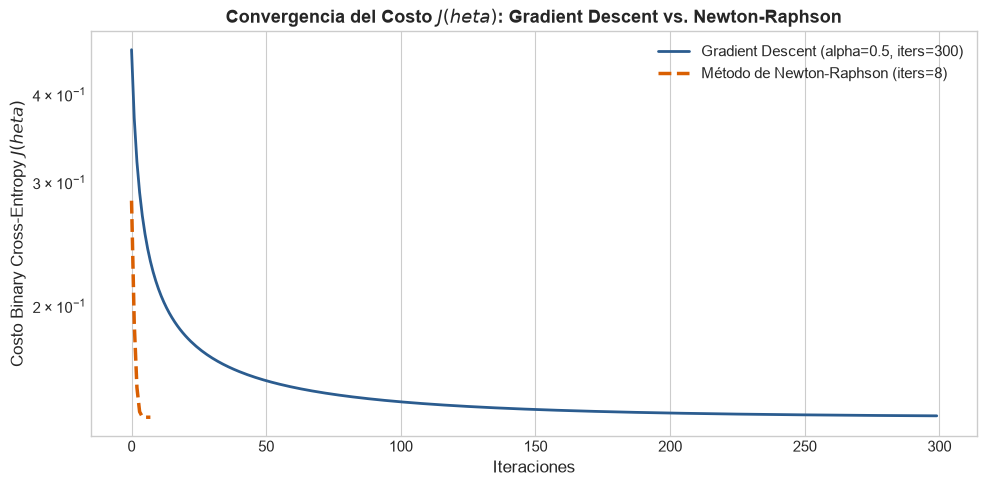

In [3]:
# Prueba de convergencia sintética
X_syn, y_syn = make_classification(
    n_samples=500, n_features=2, n_redundant=0, n_informative=2,
    random_state=42, n_clusters_per_class=1, class_sep=1.5
)

model_gd = LogisticRegressionScratch(lr=0.5, n_iters=300, method='gradient_descent').fit(X_syn, y_syn)
model_newton = LogisticRegressionScratch(n_iters=20, method='newton').fit(X_syn, y_syn)
model_sklearn = LogisticRegression(solver='lbfgs').fit(X_syn, y_syn)

print("=== Comparativa de Parámetros ===")
print(f"Gradient Descent Theta : {np.round(model_gd.theta, 4)} (Iters: {len(model_gd.cost_history)})")
print(f"Newton-Raphson Theta   : {np.round(model_newton.theta, 4)} (Iters: {len(model_newton.cost_history)})")
print(f"Scikit-Learn Coeffs    : {np.round(np.append(model_sklearn.intercept_, model_sklearn.coef_), 4)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(model_gd.cost_history, label=f'Gradient Descent (alpha=0.5, iters={len(model_gd.cost_history)})', color='#2b5c8f', lw=2)
ax.plot(model_newton.cost_history, label=f'Método de Newton-Raphson (iters={len(model_newton.cost_history)})', color='#d95f02', lw=2.5, linestyle='--')
ax.set_title('Convergencia del Costo $J(\theta)$: Gradient Descent vs. Newton-Raphson', weight='bold')
ax.set_xlabel('Iteraciones')
ax.set_ylabel('Costo Binary Cross-Entropy $J(\theta)$')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Fronteras de Decisión No Lineales y Regularización $L_2$

Extendemos el espacio de entrada mediante **expansión polinomial de características** (*Polynomial Features*) para clasificar datos no separables linealmente.


<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_6004\480648875.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.suptitle('Impacto de la Regularización $L_2$ ($C = 1/\lambda$) en Fronteras No Lineales', weight='bold', y=1.02)


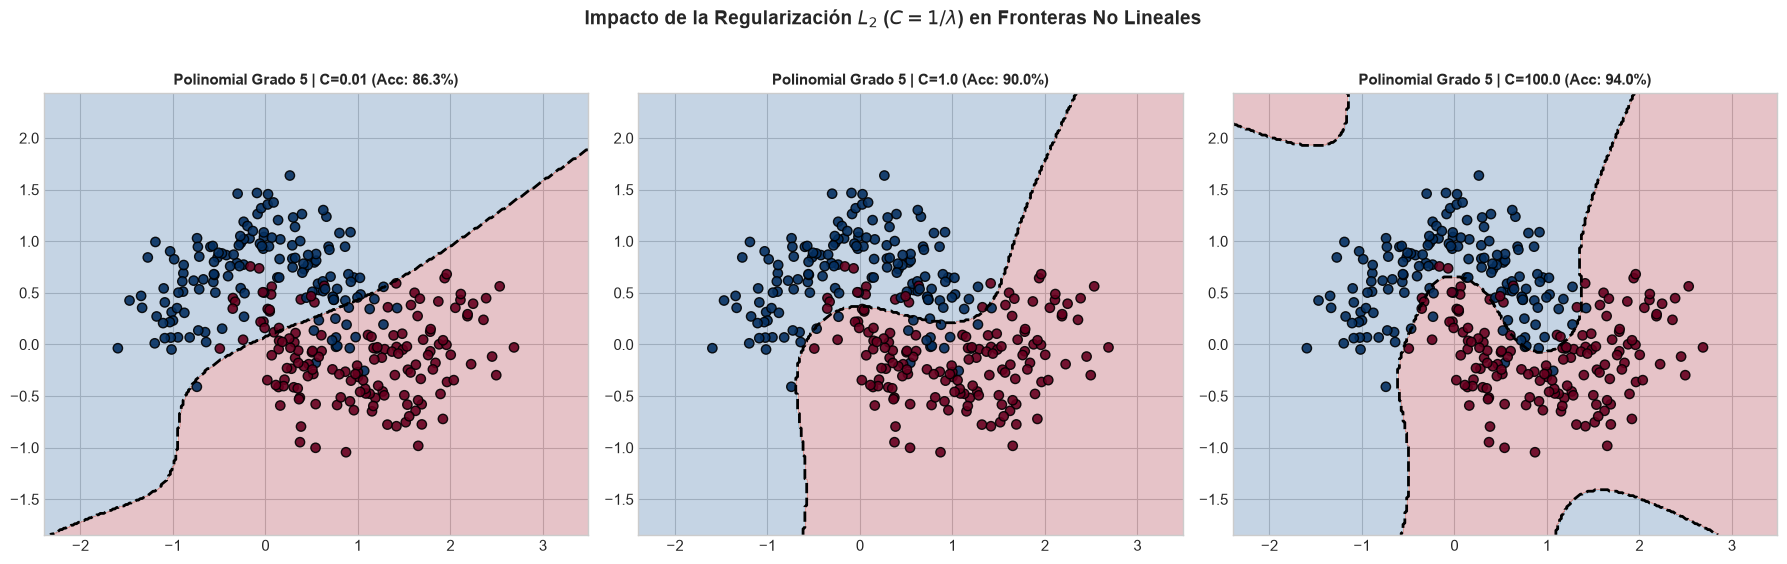

In [4]:
def plot_decision_boundary(model_func, X, y, ax, title="Frontera de Decisión"):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    
    Z = model_func.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu_r')
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.0, linestyles='--')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolors='k', s=45, alpha=0.9)
    ax.set_title(title, weight='bold', fontsize=11)

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)
C_values = [0.01, 1.0, 100.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for idx, C_val in enumerate(C_values):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=5, include_bias=False)),
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(C=C_val, solver='lbfgs', max_iter=1000))
    ])
    pipe.fit(X_moons, y_moons)
    acc = pipe.score(X_moons, y_moons)
    plot_decision_boundary(pipe, X_moons, y_moons, axes[idx], title=f"Polinomial Grado 5 | C={C_val} (Acc: {acc*100:.1f}%)")

plt.suptitle('Impacto de la Regularización $L_2$ ($C = 1/\lambda$) en Fronteras No Lineales', weight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Regresión Logística Multiclase (Softmax / One-vs-Rest)

Demostración en el dataset Iris ($K=3$ clases) utilizando la función **Softmax**:
$$P(y = k \mid x; \Theta) = \frac{e^{\theta^{(k)T} x}}{\sum_{j=1}^K e^{\theta^{(j)T} x}}$$


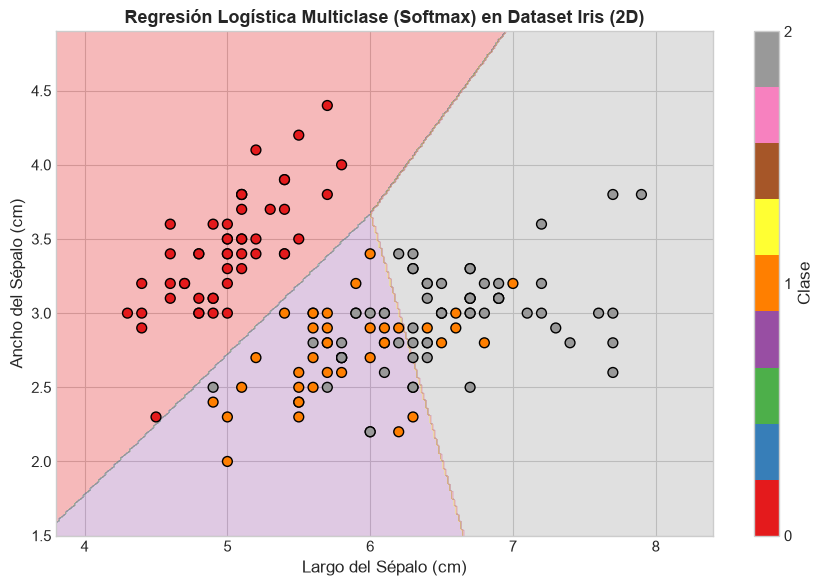

In [5]:
iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target

softmax_reg = LogisticRegression(solver='lbfgs', C=10.0, max_iter=1000).fit(X_iris, y_iris)

fig, ax = plt.subplots(figsize=(9, 6))
x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z_multi = softmax_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z_multi, alpha=0.3, cmap='Set1')
scatter = ax.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='Set1', edgecolors='k', s=50)

ax.set_title('Regresión Logística Multiclase (Softmax) en Dataset Iris (2D)', weight='bold')
ax.set_xlabel('Largo del Sépalo (cm)')
ax.set_ylabel('Ancho del Sépalo (cm)')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Clase')
plt.tight_layout()
plt.show()


## 4. Evaluación de Desempeño y Matrices de Confusión

La **Matriz de Confusión** permite desglosar las predicciones del clasificador comparando las clases reales con las predichas:
- **Verdaderos Positivos (TP)** y **Verdaderos Negativos (TN)**: Clasificaciones correctas.
- **Falsos Positivos (FP - Error Tipo I)**: Falsas alarmas.
- **Falsos Negativos (FN - Error Tipo II)**: Casos omitidos.

A continuación, evaluamos las matrices de confusión tanto para clasificación binaria sintética como para clasificación multiclase (Iris).

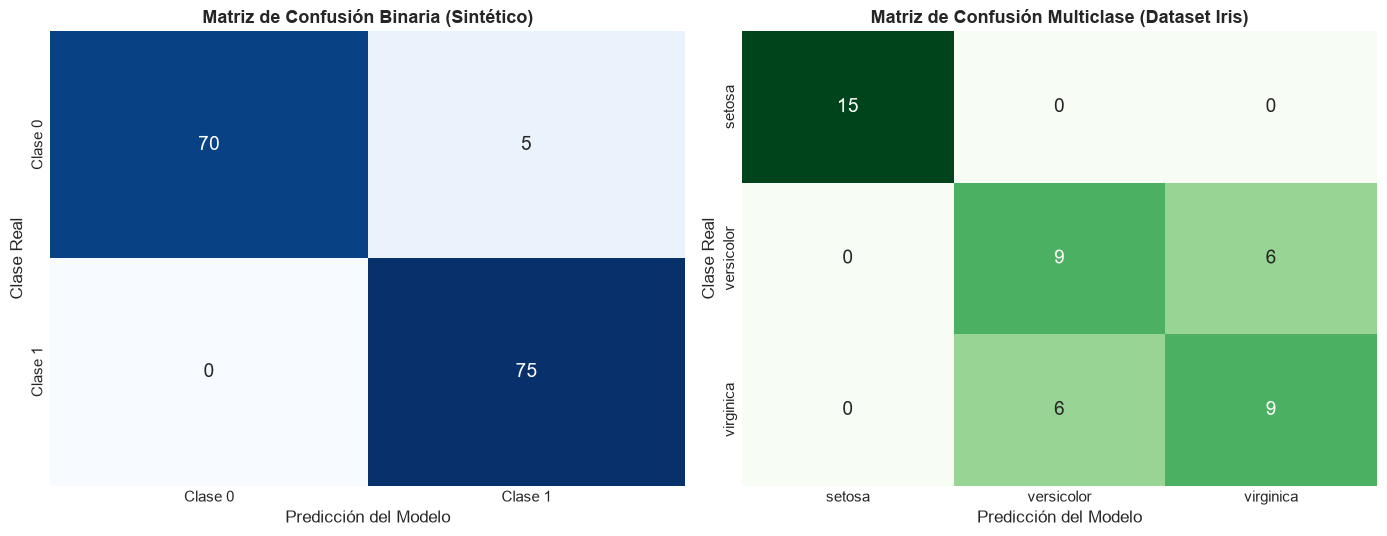

=== Reporte de Clasificación (Dataset Binario Sintético) ===
              precision    recall  f1-score   support

     Clase 0       1.00      0.93      0.97        75
     Clase 1       0.94      1.00      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [6]:
# Partición Train/Test para el dataset sintético binario
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn
)

model_syn = LogisticRegression(solver='lbfgs').fit(X_train_syn, y_train_syn)
y_pred_syn = model_syn.predict(X_test_syn)
y_proba_syn = model_syn.predict_proba(X_test_syn)[:, 1]

# Partición Train/Test para el dataset Iris (Multiclase)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)
model_iris = LogisticRegression(solver='lbfgs', max_iter=1000).fit(X_train_iris, y_train_iris)
y_pred_iris = model_iris.predict(X_test_iris)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Matriz de Confusión Binaria Sintética
cm_syn = confusion_matrix(y_test_syn, y_pred_syn)
sns.heatmap(cm_syn, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'], annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusión Binaria (Sintético)', weight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Clase Real')

# 2. Matriz de Confusión Multiclase (Iris)
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=iris.target_names, yticklabels=iris.target_names, annot_kws={"size": 14})
axes[1].set_title('Matriz de Confusión Multiclase (Dataset Iris)', weight='bold')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Clase Real')

plt.tight_layout()
plt.show()

print("=== Reporte de Clasificación (Dataset Binario Sintético) ===")
print(classification_report(y_test_syn, y_pred_syn, target_names=['Clase 0', 'Clase 1']))


## 5. Curvas de Aprendizaje (Learning Curves)

Las **Curvas de Aprendizaje** grafican el desempeño (ej. F1-Score o Accuracy) en función del tamaño del conjunto de entrenamiento.
Permiten diagnosticar los dos problemas centrales en Machine Learning:
- **Sesgo Alto (Underfitting)**: Tanto la curva de entrenamiento como la de validación se estabilizan en un puntaje bajo.
- **Varianza Alta (Overfitting)**: Existe una gran brecha (*gap*) no convergente entre la curva de entrenamiento (alta) y la de validación (baja).


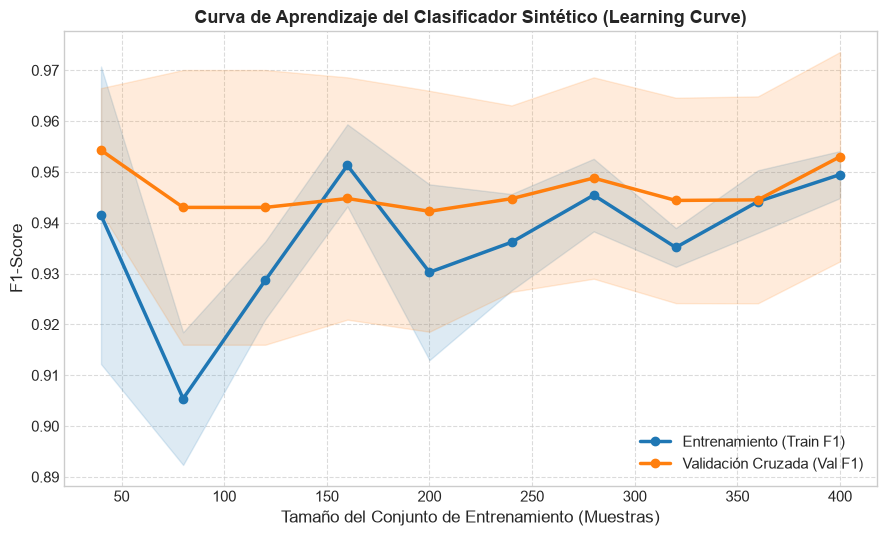

In [7]:
# Cálculo de la Curva de Aprendizaje con Validación Cruzada (5-Fold Stratified)
train_sizes, train_scores, val_scores = learning_curve(
    model_syn, X_syn, y_syn,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(9, 5.5))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', lw=2.5, label='Entrenamiento (Train F1)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

plt.plot(train_sizes, val_mean, 'o-', color='#ff7f0e', lw=2.5, label='Validación Cruzada (Val F1)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#ff7f0e')

plt.title('Curva de Aprendizaje del Clasificador Sintético (Learning Curve)', weight='bold')
plt.xlabel('Tamaño del Conjunto de Entrenamiento (Muestras)')
plt.ylabel('F1-Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 6. Curvas ROC (AUC) y Precision-Recall

- **Curva ROC (Receiver Operating Characteristic)**: Grafica la Tasa de Verdaderos Positivos (Sensibilidad/Recall) vs Tasa de Falsos Positivos ($1 - \text{Especificidad}$) a lo largo de todos los umbrales posibles. El **Área Bajo la Curva (ROC-AUC)** mide la capacidad global del modelo de separar ambas clases.
- **Curva Precision-Recall**: Grafica la Precision vs Recall. Es especialmente útil en escenarios con datos desbalanceados.

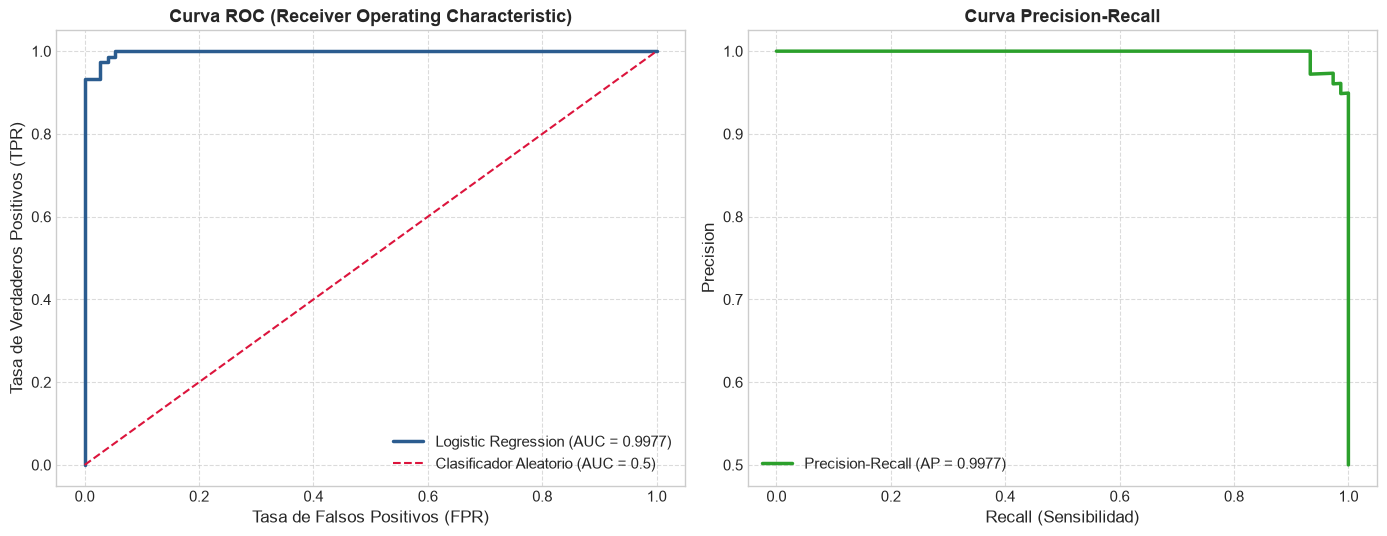

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Curva ROC
fpr, tpr, _ = roc_curve(y_test_syn, y_proba_syn)
auc_val = roc_auc_score(y_test_syn, y_proba_syn)

axes[0].plot(fpr, tpr, color='#2b5c8f', lw=2.5, label=f'Logistic Regression (AUC = {auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='crimson', linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
axes[0].set_title('Curva ROC (Receiver Operating Characteristic)', weight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Curva Precision-Recall
precisions, recalls, _ = precision_recall_curve(y_test_syn, y_proba_syn)
ap_val = average_precision_score(y_test_syn, y_proba_syn)

axes[1].plot(recalls, precisions, color='#2ca02c', lw=2.5, label=f'Precision-Recall (AP = {ap_val:.4f})')
axes[1].set_title('Curva Precision-Recall', weight='bold')
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 7. Análisis de Sensibilidad al Umbral de Decisión (Decision Threshold Tuning)

Por defecto, la Regresión Logística asigna la clase $y=1$ cuando la probabilidad estimada $h_\theta(x) \ge 0.5$.
Sin embargo, variar este umbral $\tau \in (0, 1)$ permite ajustar el compromiso (*trade-off*) entre Precision y Recall de acuerdo al contexto del negocio u objetivo práctico.

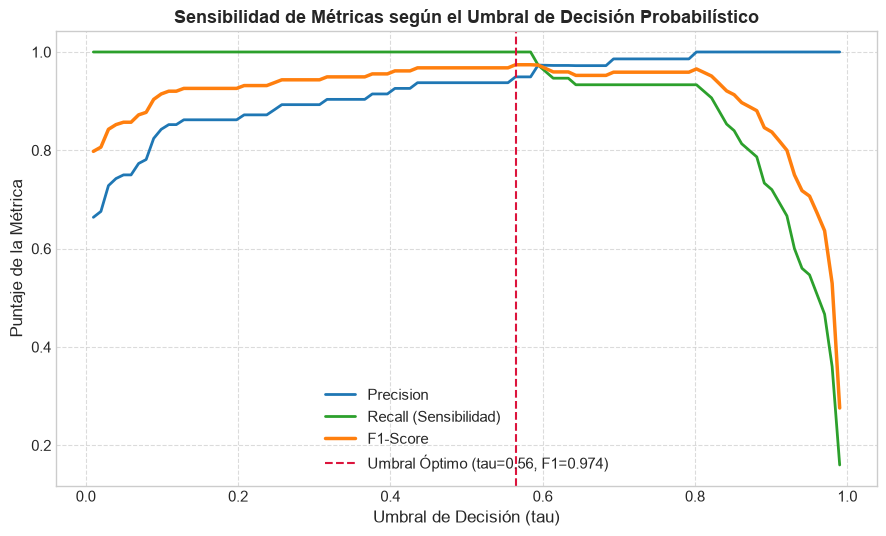

In [9]:
thresholds = np.linspace(0.01, 0.99, 100)
prec_list = []
rec_list = []
f1_list = []

for thresh in thresholds:
    preds = (y_proba_syn >= thresh).astype(int)
    prec_list.append(precision_score(y_test_syn, preds, zero_division=0))
    rec_list.append(recall_score(y_test_syn, preds, zero_division=0))
    f1_list.append(f1_score(y_test_syn, preds, zero_division=0))

best_idx = np.argmax(f1_list)
best_tau = thresholds[best_idx]
best_f1_val = f1_list[best_idx]

plt.figure(figsize=(9, 5.5))
plt.plot(thresholds, prec_list, label='Precision', color='#1f77b4', lw=2)
plt.plot(thresholds, rec_list, label='Recall (Sensibilidad)', color='#2ca02c', lw=2)
plt.plot(thresholds, f1_list, label='F1-Score', color='#ff7f0e', lw=2.5)
plt.axvline(best_tau, color='crimson', linestyle='--', label=f'Umbral Óptimo (tau={best_tau:.2f}, F1={best_f1_val:.3f})')

plt.title('Sensibilidad de Métricas según el Umbral de Decisión Probabilístico', weight='bold')
plt.xlabel('Umbral de Decisión (tau)')
plt.ylabel('Puntaje de la Métrica')
plt.legend(loc='lower center')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 8. Conclusiones y Resumen Didáctico

1. **Matrices de Confusión**: Proporcionan una vista detallada del desempeño discriminativo permitiendo identificar Falsos Positivos y Falsos Negativos tanto en problemas binarios como multiclase.
2. **Curvas de Aprendizaje**: Permiten verificar la convergencia del entrenamiento, diagnosticar de forma visual sesgo vs. varianza y determinar si se requieren más datos de entrenamiento o modelos de mayor capacidad.
3. **Curvas ROC-AUC y Precision-Recall**: Evalúan la calidad probabilística del clasificador de manera independiente al umbral elegido.
4. **Optimización del Umbral de Decisión**: Ajustar el umbral $\tau$ permite adaptar el clasificador a objetivos específicos donde el costo de un Falso Negativo difiere del de un Falso Positivo.